# Hybrid Movie Recommender — Demo

A self-contained walkthrough of the trained model: fold in a taste profile, then score and rank movies against it. No network access or personal data required — the profile below is a synthetic, illustrative one (a few well-known titles with made-up ratings), not a real Letterboxd export.

For the full pipeline (a real Letterboxd export in, TMDB matching, content-feature fetch, training), see `README.md`.

In [1]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt

sys.path.insert(0, str(Path.cwd().parent))
from engine.content import load_hybrid_artifacts
from engine.paths import DATA_DIR
from engine.recommend import fold_in_user, load_movie_metadata, predict_rating

## Load the trained model

`hybrid_mf_artifacts.npz` — item + content-feature embeddings from `scripts/train_hybrid_mf.py`. `movies.csv` — MovieLens's title/genre lookup.

In [2]:
artifacts = load_hybrid_artifacts(DATA_DIR / "hybrid_mf_artifacts.npz")
meta = load_movie_metadata(DATA_DIR / "ml-32m" / "movies.csv")

print(f"{len(artifacts['movie_ids']):,} movies with a trained identity embedding")
print(f"embedding dimension k = {artifacts['item_embeddings'].shape[1]}")

23,350 movies with a trained identity embedding
embedding dimension k = 64


## A synthetic taste profile

Standing in for a Letterboxd export: 22 ratings, sci-fi/action loved (`The Matrix`, `Inception`, `Alien`, `Dune`, ...), romance/melodrama disliked (`Titanic`, `The Notebook`, `27 Dresses`, ...) -- both directions, not just high ratings, so Ridge has real signal to fit. `find_movie` below does the same case-insensitive, year-disambiguated substring search `scripts/predict.py` uses.

In [3]:
import re

YEAR_RE = re.compile(r"\((\d{4})\)\s*$")


def find_movie(title_query, year, meta):
    q = title_query.lower()
    for mid, (t, g) in meta.items():
        if q in t.lower():
            m = YEAR_RE.search(t)
            if m and int(m.group(1)) == year:
                return mid, t, g
    return None


# 22 ratings -- deliberately within the 20-286 profile-size range
# fold_in_user's default alpha was actually cross-validated against (see its
# docstring); a much smaller profile under-uses the regularization the
# tuned alpha assumes and fold-in leans closer to a bias-only fit. A clear
# taste signal (loves sci-fi/action, dislikes romance/melodrama) on both
# sides, not just high ratings, gives Ridge something to actually fit.
SYNTHETIC_PROFILE = [
    ("Matrix", 1999, 5.0),
    ("Inception", 2010, 5.0),
    ("Interstellar", 2014, 5.0),
    ("Mad Max: Fury Road", 2015, 4.5),
    ("Dune", 2021, 4.5),
    ("Dark Knight", 2008, 4.5),
    ("Terminator 2", 1991, 4.5),
    ("Alien", 1979, 4.5),
    ("Blade Runner", 1982, 4.0),
    ("Edge of Tomorrow", 2014, 4.0),
    ("Guardians of the Galaxy", 2014, 4.0),
    ("Avengers", 2012, 4.0),
    ("Star Wars: Episode IV", 1977, 4.5),
    ("Aliens", 1986, 4.5),
    ("Groundhog Day", 1993, 3.5),
    ("Whiplash", 2014, 4.0),
    ("Parasite", 2019, 4.0),
    ("La La Land", 2016, 2.0),
    ("Notebook", 2004, 1.5),
    ("Titanic", 1997, 2.0),
    ("27 Dresses", 2008, 1.5),
    ("Pretty Woman", 1990, 2.0),
]

matched = []
for title, year, rating in SYNTHETIC_PROFILE:
    hit = find_movie(title, year, meta)
    if hit is None:
        print(f"  [skip] {title!r} ({year}) not found")
        continue
    movie_id, full_title, genres = hit
    matched.append({"movieId": movie_id, "rating": rating})
    print(f"  {rating:.1f}  {full_title}")

print(f"\n{len(matched)} ratings matched to MovieLens")

  5.0  Matrix, The (1999)
  5.0  Inception (2010)
  5.0  Interstellar (2014)
  4.5  Mad Max: Fury Road (2015)
  4.5  Dune (2021)
  4.5  Dark Knight, The (2008)
  4.5  Terminator 2: Judgment Day (1991)
  4.5  Alien (1979)
  4.0  Blade Runner (1982)
  4.0  Edge of Tomorrow (2014)
  4.0  Guardians of the Galaxy (2014)
  4.0  Avengers, The (2012)
  4.5  Star Wars: Episode IV - A New Hope (1977)
  4.5  Aliens (1986)
  3.5  Groundhog Day (1993)
  4.0  Whiplash (2014)
  4.0  Parasite (2019)
  2.0  La La Land (2016)
  1.5  Notebook, The (2004)
  2.0  Titanic (1997)
  1.5  27 Dresses (2008)
  2.0  Pretty Woman (1990)

22 ratings matched to MovieLens


## Fold in

`fold_in_user` fits a Ridge regression against the frozen item embeddings — a few milliseconds, not a retrain (see its docstring in `engine/recommend.py` for the full rationale and the cross-validation behind its default `alpha`).

In [4]:
user_vector, user_bias = fold_in_user(matched, artifacts)
print(f"user_vector norm: {(user_vector ** 2).sum() ** 0.5:.3f}   user_bias: {user_bias:+.3f}")

user_vector norm: 0.234   user_bias: +0.051


## Score every unrated movie, show the top 15

In [5]:
already_rated = {m["movieId"] for m in matched}

scored = []
for movie_id, idx in artifacts["movieid_to_idx"].items():
    if movie_id in already_rated:
        continue
    title, genres = meta.get(movie_id, (None, ""))
    if title is None:
        continue
    item_vector = artifacts["item_embeddings"][idx]
    item_bias = float(artifacts["item_biases"][idx])
    raw = predict_rating(user_vector, user_bias, item_vector, item_bias, artifacts["global_mean"])
    scored.append((max(0.5, min(5.0, raw)), title, genres))

scored.sort(key=lambda row: row[0], reverse=True)
top15 = scored[:15]

for clamped, title, genres in top15:
    print(f"  {clamped:.2f}/5.0  {title}  [{genres}]")

  4.67/5.0  Planet Earth II (2016)  [Documentary]
  4.61/5.0  Blue Planet II (2017)  [Documentary]
  4.53/5.0  Planet Earth (2006)  [Documentary]
  4.48/5.0  Matrix Reloaded, The (2003)  [Action|Adventure|Sci-Fi|Thriller|IMAX]
  4.43/5.0  Unforgiven, The (1960)  [Drama|Western]
  4.43/5.0  Lord of the Rings: The Fellowship of the Ring, The (2001)  [Adventure|Fantasy]
  4.41/5.0  The Blue Planet (2001)  [Documentary]
  4.40/5.0  Lord of the Rings: The Return of the King, The (2003)  [Action|Adventure|Drama|Fantasy]
  4.40/5.0  Matrix Revolutions, The (2003)  [Action|Adventure|Sci-Fi|Thriller|IMAX]
  4.38/5.0  Annihilation (2018)  [Adventure|Mystery|Sci-Fi|Thriller]
  4.35/5.0  Cell, The (2000)  [Drama|Horror|Thriller]
  4.35/5.0  Cosmos  [(no genres listed)]
  4.35/5.0  Lord of the Rings: The Two Towers, The (2002)  [Adventure|Fantasy]
  4.32/5.0  Alien: Resurrection (1997)  [Action|Horror|Sci-Fi]
  4.32/5.0  Forgetting Sarah Marshall (2008)  [Comedy|Romance]


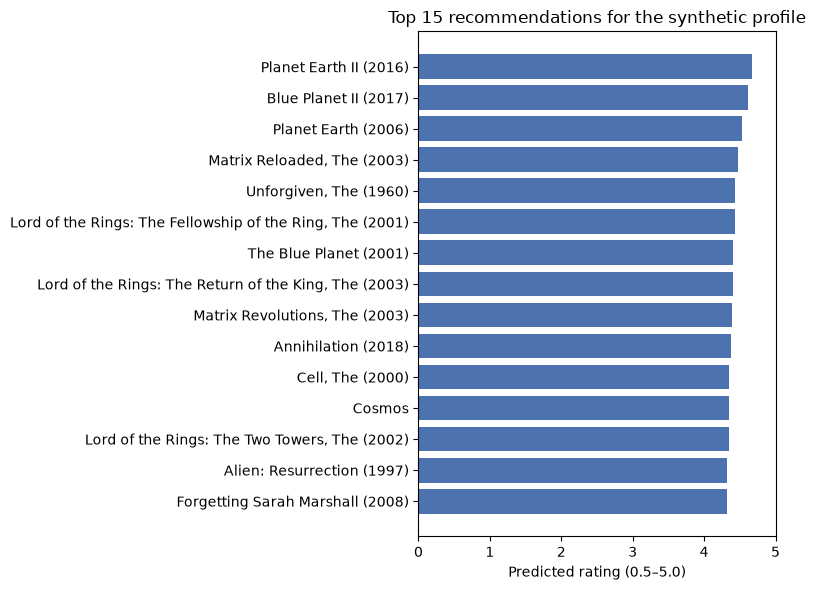

In [6]:
titles = [t for _, t, _ in reversed(top15)]
scores = [s for s, _, _ in reversed(top15)]

plt.figure(figsize=(8, 6))
plt.barh(titles, scores, color="#4C72B0")
plt.xlabel("Predicted rating (0.5–5.0)")
plt.title("Top 15 recommendations for the synthetic profile")
plt.xlim(0, 5)
plt.tight_layout()
plt.show()

A few nature documentaries (`Planet Earth II`, `Blue Planet II`) outrank plenty of genuinely on-theme sci-fi here (`Matrix Reloaded`, the `Lord of the Rings` trilogy, `Annihilation`, `Alien: Resurrection` do show up, just not at the very top). That's the `item_bias` term at work -- a handful of near-universally-loved niche titles carry a large learned bias regardless of genre, and with only 22 ratings the personalization term doesn't always outweigh it. `scripts/recommend.py --min-support-sim` exists specifically to filter this kind of case (requiring a candidate to be embedding-similar to something the user actually rated, not just globally popular) -- worth trying against this same profile.

## Try your own profile

Edit `SYNTHETIC_PROFILE` above with your own titles/years/ratings and re-run — or for a real Letterboxd export, use the actual CLI pipeline (`scripts/fetch_tmdb_metadata.py` → `scripts/match_movielens.py` → `scripts/predict.py`/`scripts/recommend.py`), which also handles movies with no MovieLens entry at all via a live TMDB fetch.